In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import Lasso, Ridge

In [7]:
data = load_diabetes()

In [10]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target 

In [11]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [14]:
df.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


In [15]:
df.cov()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,0.002268,0.000394,0.000420,0.000761,0.000590,0.000497,-0.000170,0.000462,0.000614,0.000684,0.689758
sex,0.000394,0.002268,0.000200,0.000547,0.000080,0.000323,-0.000860,0.000753,0.000340,0.000472,0.158085
bmi,0.000420,0.000200,0.002268,0.000897,0.000566,0.000592,-0.000832,0.000938,0.001012,0.000881,2.152914
bp,0.000761,0.000547,0.000897,0.002268,0.000550,0.000421,-0.000405,0.000584,0.000892,0.000885,1.620722
s1,0.000590,0.000080,0.000566,0.000550,0.002268,0.002033,0.000117,0.001229,0.001169,0.000739,0.778355
s2,0.000497,0.000323,0.000592,0.000421,0.002033,0.002268,-0.000445,0.001496,0.000722,0.000659,0.638967
s3,-0.000170,-0.000860,-0.000832,-0.000405,0.000117,-0.000445,0.002268,-0.001675,-0.000904,-0.000621,-1.449309
s4,0.000462,0.000753,0.000938,0.000584,0.001229,0.001496,-0.001675,0.002268,0.001401,0.000946,1.580234
s5,0.000614,0.000340,0.001012,0.000892,0.001169,0.000722,-0.000904,0.001401,0.002268,0.001054,2.077409
s6,0.000684,0.000472,0.000881,0.000885,0.000739,0.000659,-0.000621,0.000946,0.001054,0.002268,1.404133


In [19]:
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,:-1],df['target'],test_size=0.2,random_state=42)

In [51]:
lasso = Lasso(alpha=0.1)

In [52]:
lasso.fit(X_train,y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [53]:
y_pred = lasso.predict(X_test)

In [54]:
r2_score(y_test,y_pred)

0.4718547867276227

In [55]:
lasso.coef_

array([   0.        , -152.66477923,  552.69777529,  303.36515791,
        -81.36500664,   -0.        , -229.25577639,    0.        ,
        447.91952518,   29.64261704])

In [56]:
lasso.intercept_

np.float64(151.57485282893947)

In [58]:
ridge = Ridge(alpha=0.1)

In [59]:
ridge.fit(X_train,y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [60]:
ridge.coef_

array([  42.85566976, -205.49431899,  505.08903304,  317.0932049 ,
       -108.50026183,  -86.23673333, -190.36318008,  151.70708637,
        392.28931896,   79.9081772 ])

In [50]:
alpha = [0.1,1,10]
coef_ = []
r2_scores = []

for i in alpha:
    lasso = Lasso(alpha=i)
    lasso.fit(X_train,y_train)
    y_pred = lasso.predict(X_test)

    coef_.append(lasso.coef_.tolist())
    r2_scores.append(r2_score(y_test,y_pred))

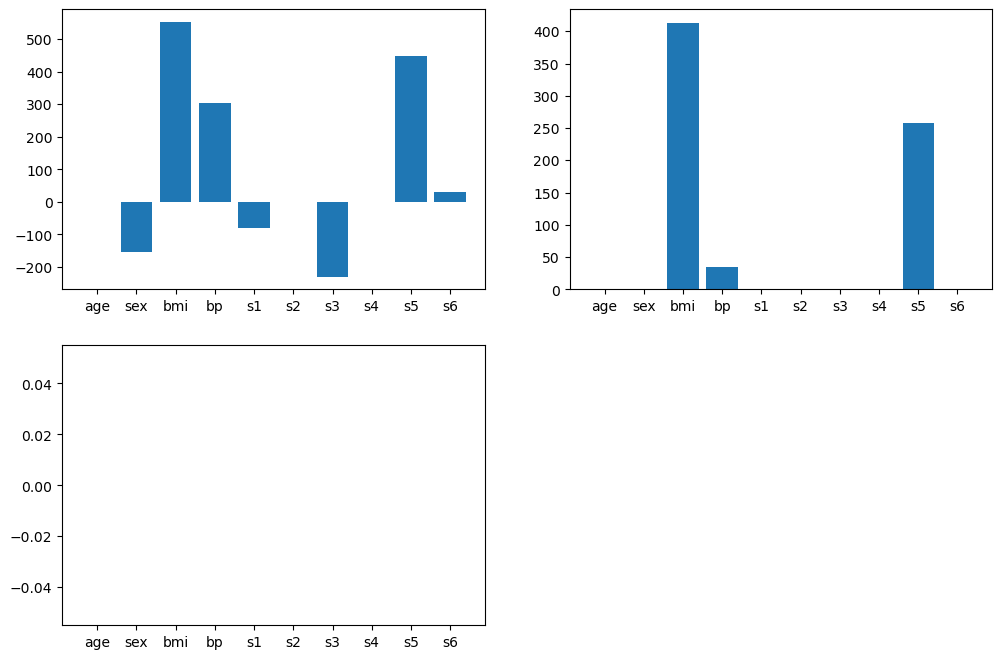

In [65]:
plt.figure(figsize=(12,8))
plt.subplot(221)
plt.bar(data.feature_names,coef_[0])

plt.subplot(222)
plt.bar(data.feature_names,coef_[1])

plt.subplot(223)
plt.bar(data.feature_names,coef_[2])


plt.show()

In [39]:
a

[1, 2, 3, 2, [1, 2]]